**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import joblib

**Load Clean Dataset**

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/PRIYAGUNAR/IIMSTC-Cohort10-Urban-AQI-Modeler/main/cleaned_air_quality_data%20(1)%20(1).csv")


In [3]:
data.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,datetime,Hour
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,6,4.4,2013-03-01 00:00:00,0
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,3,4.7,2013-03-01 01:00:00,1
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,6,5.6,2013-03-01 02:00:00,2
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,7,3.1,2013-03-01 03:00:00,3
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,3,2.0,2013-03-01 04:00:00,4


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 54776 entries, 0 to 54775
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      54776 non-null  int64  
 1   month     54776 non-null  int64  
 2   day       54776 non-null  int64  
 3   hour      54776 non-null  int64  
 4   PM2.5     54776 non-null  float64
 5   PM10      54776 non-null  float64
 6   SO2       54776 non-null  float64
 7   NO2       54776 non-null  float64
 8   CO        54776 non-null  float64
 9   O3        54776 non-null  float64
 10  TEMP      54776 non-null  float64
 11  PRES      54776 non-null  float64
 12  DEWP      54776 non-null  float64
 13  RAIN      54776 non-null  float64
 14  wd        54776 non-null  int64  
 15  WSPM      54776 non-null  float64
 16  datetime  54776 non-null  str    
 17  Hour      54776 non-null  int64  
dtypes: float64(11), int64(6), str(1)
memory usage: 7.5 MB


**Define Target & Features**

In [9]:

X = data.select_dtypes(include=['number', 'bool']).drop(columns=['PM2.5'])
y = data['PM2.5']


**Train-Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)


**Evaluation Function**

In [11]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)


**Linear Regression**

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

**Random Forest**

In [13]:
from sklearn.ensemble import RandomForestRegressor
'''rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)
'''
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

**XGBoost**

In [14]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=500,         
    learning_rate=0.03,       
    max_depth=8,             
    subsample=0.8,            
    colsample_bytree=0.8,    
    reg_alpha=0.1,            
    reg_lambda=1.0,           
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

**Model comparison**

In [16]:
evaluate(y_test, pred_lr, "Linear Regression")


Linear Regression
RMSE: 29.97338692638447
MAE : 20.03053345551795
R2  : 0.85198757241538


In [17]:
evaluate(y_test, pred_rf, "Random Forest")


Random Forest
RMSE: 19.42620792417022
MAE : 11.409833772116587
R2  : 0.9378268878310767


In [18]:
evaluate(y_test, pred_xgb, "XGBoost")

XGBoost
RMSE: 16.238425117346893
MAE : 9.747130594383238
R2  : 0.9565575454500709


In [19]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV R² scores: [0.88592009 0.93009772 0.92689521 0.873796   0.9469154 ]
Mean R²: 0.9127 ± 0.0279


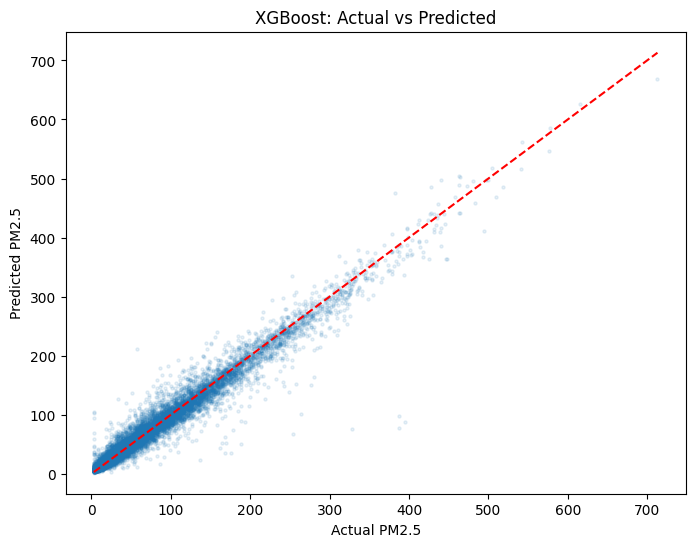

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_xgb, alpha=0.1, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

**Feature Importance**

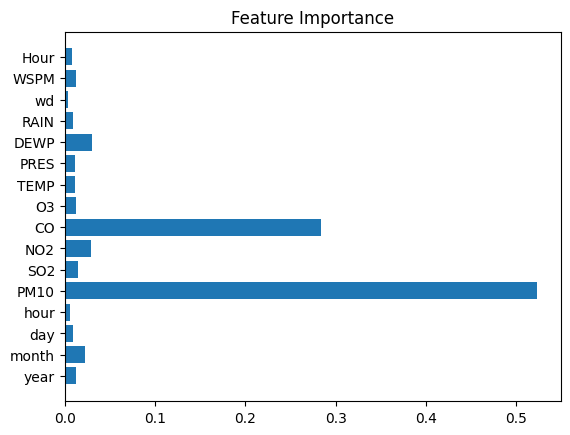

In [23]:
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

**Save Models**

In [24]:
import joblib
joblib.dump(xgb, "../models/pm25_xgb_model.pkl")

['../models/pm25_xgb_model.pkl']

In [25]:
joblib.dump(rf, "../models/pm25_rf_model.pkl")

['../models/pm25_rf_model.pkl']